In [1]:
import pandas as pd
import numpy as np
import time
import random
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

model_m2 = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device = "mps")

In [4]:
df_train = pd.read_json("../Project/IMDB_reviews_train.json", lines=True)

In [2]:
TEXT_COL = "clean_text"
LABEL_COL = "is_spoiler"
GROUP_COL = "movie_id"

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

## Test run for SBERT on Windows

In [31]:
sample_reviews = df_train[TEXT_COL].iloc[:2000]  # small subset

windows = []
batch_size = 64

for text in sample_reviews:
    sents = [sent.text for sent in nlp(text).sents]
    for i in range(len(sents) - 2):
        windows.append(" ".join(sents[i:i+3]))

start = time.perf_counter()


for i in tqdm(range(0, len(windows), batch_size), desc="Encoding windows"):
    batch = windows[i:i+batch_size]
    
    emb = model_m2.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

end = time.perf_counter()

print("Total windows:", len(windows))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows))

Encoding windows: 100%|███████████████████████| 249/249 [00:43<00:00,  5.72it/s]

Total windows: 15904
Time taken: 43.50647745805327
Time per window: 0.002735568250632122


## Small experiment

In [20]:
target = "The hero dies at the end."
prev = "The final battle begins."
next_ = "The kingdom mourns his loss."

In [24]:
plain_window = f"{prev} {target} {next_}"
marked_window = f"{prev} [TARGET] {target} [/TARGET] {next_}"
target_only = target

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

emb_plain = model_m2.encode([plain_window])[0]
emb_marked = model_m2.encode([marked_window])[0]
emb_target = model_m2.encode([target_only])[0]

sim_plain = cosine_similarity([emb_plain], [emb_target])[0][0]
sim_marked = cosine_similarity([emb_marked], [emb_target])[0][0]

print("Plain similarity:", sim_plain)
print("Marked similarity:", sim_marked)

Plain similarity: 0.7551559
Marked similarity: 0.6644263


In [34]:
df_train[SPOILER_COL].dtype

dtype('bool')

In [32]:
import random

# Load your English model
nlp = spacy.load("en_core_web_sm")

# Assume df_train has columns: TEXT_COL and SPOILER_COL (True/False)
TEXT_COL = "review_text"
SPOILER_COL = LABEL_COL

# Filter spoiler reviews
spoiler_reviews = df_train[df_train[SPOILER_COL] == "true"][TEXT_COL].tolist()

# Randomly sample 20 spoiler reviews
sample_reviews = random.sample(spoiler_reviews, min(20, len(spoiler_reviews)))

# Window size (number of sentences per window)
window_size = 3

# Process each review
for idx, review in enumerate(sample_reviews, 1):
    doc = nlp(review)
    sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
    
    print(f"\n--- Review {idx} ---\n")
    
    # Create windows
    for i in range(len(sentences) - window_size + 1):
        window = " ".join(sentences[i:i+window_size])
        print(f"Window {i+1}: {window}\n")
    
    input("Press Enter to go to next review...")


--- Review 1 ---

Window 1: When I saw the trailers for "The Dark Knight", I knew it was going to be a hit. And I wasn't disappointed. I highly enjoyed watching The Dark Knight.

Window 2: And I wasn't disappointed. I highly enjoyed watching The Dark Knight. It's got the makings of a great film; An A-List cast, great cinematography, great story, and a large fan-base.

Window 3: I highly enjoyed watching The Dark Knight. It's got the makings of a great film; An A-List cast, great cinematography, great story, and a large fan-base. The first thing that really struck me was the cinematography.

Window 4: It's got the makings of a great film; An A-List cast, great cinematography, great story, and a large fan-base. The first thing that really struck me was the cinematography. The camera-work, coloring, everything is excellent.

Window 5: The first thing that really struck me was the cinematography. The camera-work, coloring, everything is excellent. The dark nature of the story is represent

Press Enter to go to next review... 



--- Review 2 ---

Window 1: I don't usually review but thought that I'd give this a go because there are so many Kristen Stewart haters. I personally think that she is getting better with every film she makes. She is believable in this role of a girl that a has been locked away for 10 years.

Window 2: I personally think that she is getting better with every film she makes. She is believable in this role of a girl that a has been locked away for 10 years. She pulls off the innocence that the Disney Snow White had along the with the willingness to fight for her life, her land and her people.

Window 3: She is believable in this role of a girl that a has been locked away for 10 years. She pulls off the innocence that the Disney Snow White had along the with the willingness to fight for her life, her land and her people. I really want to see where they take the Snow White/Huntsman chemistry that leaped of the screen when they looked at each other.

Window 4: She pulls off the innocence t

Press Enter to go to next review... 



--- Review 3 ---

Window 1: As just a kid from Brooklyn, Captain America makes a name for himself in this extremely entertaining and engaging superhero flick. Like Superman, Captain America is Marvel Comics answer to the Red, White, and Blue, and while this movie could have been a simple set up to Marvel's The Avengers, it manages to be its own movie. Part of this is because it takes place first in the timeline of all of the Marvel Studios' movies, so there are fewer references to the other heroes who come later down the line, but this movie also focuses on showing the transformation of Steve Rogers, from scrawny kid getting beat up in the alleys of Brooklyn, to the symbol of hope for America in World War II.The movie is almost entirely set in the 1940s, featuring the Greatest Generation in all of its glory, with this movie somewhat playing as a love letter to that simpler time where evil was evil, and good was good.

Window 2: Like Superman, Captain America is Marvel Comics answer to

...

Press Enter to go to next review... 



--- Review 19 ---

Window 1: When I saw the trailer for this, I thought I could figure out the spoilers and everything about the movie. Well, the thing is, it honestly takes about 2 hours of watching the movie to get to all the spoilers. First things first, the bad thing about this film is the length.

Window 2: Well, the thing is, it honestly takes about 2 hours of watching the movie to get to all the spoilers. First things first, the bad thing about this film is the length. It's just a tad bit wee long.

Window 3: First things first, the bad thing about this film is the length. It's just a tad bit wee long. That's my only complaint.

Window 4: It's just a tad bit wee long. That's my only complaint. Honestly, I can't think of a single scene that should've been left out, but hey, I'm just an opinion and not a director.

Window 5: That's my only complaint. Honestly, I can't think of a single scene that should've been left out, but hey, I'm just an opinion and not a director. Everything

Press Enter to go to next review... 



--- Review 20 ---

Window 1: Having seen SCARFACE last night after a 22 year gap I can honestly say that I was entertained, but have to admit that the movie is nowhere near other gangster classics such as (ironically) THE GODFATHER or GOODFELLAS. SCARFACE tells the tale of Cuban "political" immigrant Tony Montana and his arrival to the U.S. and how he attains money and power beyond his wildest dreams. You don't need to be a narc or an FBI expert to tell that Montana smells of bad luck; his demeanor, the way he talks, etc. would make him an instant suspect in any police department around the world.

Window 2: SCARFACE tells the tale of Cuban "political" immigrant Tony Montana and his arrival to the U.S. and how he attains money and power beyond his wildest dreams. You don't need to be a narc or an FBI expert to tell that Montana smells of bad luck; his demeanor, the way he talks, etc. would make him an instant suspect in any police department around the world. How he manages the get IN

Press Enter to go to next review... 


## Possible hypothesis
People have different ideas of what is important to the movie experience with respect to the plot and storyline. Hence, they have different defintions of spoilers.

## Trial with Classifier

In [6]:
import random
random.seed(42)

In [7]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(df_train, groups=df_train[GROUP_COL]))

df_trainsub = df_train.iloc[train_idx]
df_val   = df_train.iloc[val_idx]

In [8]:
spoiler = df_trainsub[df_trainsub[LABEL_COL] == True]
non_spoiler = df_trainsub[df_trainsub[LABEL_COL] == False]

n = 10000  # per class

df_sample = pd.concat([
    spoiler.sample(n, random_state=42),
    non_spoiler.sample(n, random_state=42)
]).sample(frac=1, random_state=42)

In [9]:
spoiler_val = df_val[df_val[LABEL_COL] == True]
non_spoiler_val = df_val[df_val[LABEL_COL] == False]

n = 100  # per class

df_sample_test = pd.concat([
    spoiler_val.sample(n, random_state=42),
    non_spoiler_val.sample(n, random_state=42)
]).sample(frac=1, random_state=42)

## Sampling Windows

## With sampling toggle (for testing)

In [5]:
'''
import spacy
nlp = spacy.load("en_core_web_sm")  # or your preferred SpaCy model
'''

def sample_windows_with_labels_ids(df, text_col, label_col, window_width = 1, max_windows=3, min_words=5, sample=True):
    windows = []
    labels = []
    review_ids = []
    review_label_map = {}   # NEW

    for rid, row in enumerate(df.itertuples(), start=0):
        text = getattr(row, text_col)
        label = getattr(row, label_col)

        review_label_map[rid] = label   # store mapping

        sents = [sent.text.strip() for sent in nlp(text).sents if len(sent.text.split()) >= min_words]
        if not sents:
            continue

        if sample:
            chosen_indices = random.sample(range(len(sents)), min(max_windows, len(sents)))
        else:
            chosen_indices = range(len(sents))

        for idx in chosen_indices:
            start = max(0, idx - window_width)
            end = min(len(sents), idx + window_width + 1)
            window = " ".join(sents[start:end])

            windows.append(window)
            labels.append(label)
            review_ids.append(rid)

    return windows, labels, review_ids, review_label_map

### Windows <= 3, Sentence >= 5 words

In [12]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=3,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

Total windows: 59192
Time taken: 825.9825370420003
Time per window: 0.0139542934356332


In [18]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=3,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 8.052207167027518
Time per window: 0.0034090631528482297


In [130]:
windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    max_windows=3,
    min_words=5,
    sample=False
)

## Window Width = 1, Window count = 5, Sentence >=5

In [12]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=5,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

NameError: name 'windows' is not defined

In [11]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=5,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 8.615055416012183
Time per window: 0.003647356230318452


## Window Width = 1, Window count = 7, Sentence >= 5

In [13]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

Total windows: 127347
Time taken: 830.5408098750049
Time per window: 0.006521871813823686


In [12]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 9.41991745796986
Time per window: 0.003988110693467341


### Window Width = 2 (5 sentences), Sentence >= 5 words, Window count 3

In [11]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=3,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows))

Total windows: 59192
Time taken: 864.4785461659776
Time per window: 0.014604651746282903


In [10]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=3,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 11.098668291931972
Time per window: 0.004698843476685847


## Window Width = 2 (5 sentences), Sentence >= 5 words, Window count: 5

In [15]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=5,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

NameError: name 'windows' is not defined

In [10]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=5,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 8.975631459034048
Time per window: 0.003800013318812044


## Window Width = 2 (5 sentences), Sentence >= 5 words, Window count 7

In [13]:
'''
Train
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    df_sample,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

Total windows: 127347
Time taken: 880.3517523750197
Time per window: 0.00691301524476446


In [10]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    df_sample_test,
    TEXT_COL,
    LABEL_COL,
    window_width=2,
    max_windows=7,
    min_words=5,
    sample=False
)

end = time.perf_counter()

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 2362
Time taken: 8.694504374987446
Time per window: 0.0036809925380979873


## Generate BERT Embeddings

In [11]:
def generate_SBERT_emb(SBERT, windows, batch_size=64, to_numpy=True, normalize=True):
    X_test_emb = []
    
    start = time.perf_counter()
    
    for i in tqdm(range(0, len(windows), batch_size), desc="Encoding windows"):
        batch = windows[i:i+batch_size]
        
        emb = SBERT.encode(
            batch,
            convert_to_numpy=to_numpy,
            normalize_embeddings=normalize
        )
        X_test_emb.append(emb)
    
    X_test_emb = np.vstack(X_test_emb)
    
    end = time.perf_counter()
    
    print("Total windows:", len(X_test_emb))
    print("Time taken:", end - start)
    print("Time per window:", (end - start)/len(X_test_emb))

    return X_test_emb

In [18]:
X_train_emb = generate_SBERT_emb(model_m2, windows_train)

Encoding windows: 100%|█████████████████████| 1990/1990 [09:02<00:00,  3.67it/s]


Total windows: 127347
Time taken: 543.4506976660341
Time per window: 0.004267479388332934


In [12]:
X_test_emb = generate_SBERT_emb(model_m2, windows_test)

Encoding windows: 100%|█████████████████████████| 37/37 [00:13<00:00,  2.77it/s]

Total windows: 2362
Time taken: 13.386630708002485
Time per window: 0.005667498182896903


In [20]:
window = 1541
print(X_test_emb[window][0:10])
print(windows_test[window])
print(labels_test[window])
print(ids_test[window])

[-0.0654211   0.02039429 -0.04108269  0.02456233  0.04095963  0.09593799
  0.02846187 -0.01132999  0.0508735  -0.02059478]
although the film has a lot of violence and fighting there are some comic moments too and there are some scenes when you almost forget to breathe!! the fact it is based on a true story and the actors playing real life people brings it home that things like this do go on in the world. my favourite film ever and always will be...
False
135


## Saving data

In [15]:
import pickle
import numpy as np

# Assume these are already defined
# embeddings: list or np.array of SBERT vectors, shape (num_windows, embedding_dim)
# labels: list or np.array of 0/1 labels per window
# review_ids: list or np.array of review IDs per window
# review_label_map: dict mapping review_id -> true review label

def save_data(embeddings, windows, labels, review_ids, review_label_map, folder):
    data_to_save = {
        "embeddings": np.array(embeddings),      # convert to np.array if not already
        "labels": np.array(labels),
        "review_ids": np.array(review_ids),
        "review_label_map": review_label_map     # dictionary
    }
    
    with open(f"{folder}/sbert_window_data.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    with open(f"{folder}/windows.pkl", "wb") as f:
        pickle.dump(windows, f)
    
    print("Saved embeddings, labels, review IDs, and review_label_map in one file!")

In [16]:
save_data(X_test_emb, windows_test, labels_test, ids_test, ids_map_test, "../Project/s5w7/test")

Saved embeddings, labels, review IDs, and review_label_map in one file!


In [17]:
save_data(X_train_emb, windows_train, labels_train, ids_train, ids_map_train, "../Project/s5w7/train")

Saved embeddings, labels, review IDs, and review_label_map in one file!


## Load data

In [1]:
import pickle

def load_data(folder):
    # Load main data
    with open(f"{folder}/sbert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    # Load windows
    with open(f"{folder}/windows.pkl", "rb") as f:
        windows = pickle.load(f)
    
    embeddings = data["embeddings"]
    labels = data["labels"]
    review_ids = data["review_ids"]
    review_label_map = data["review_label_map"]
    
    return embeddings, windows, labels, review_ids, review_label_map

In [2]:
X_train_emb, windows_train, labels_train, ids_train, ids_map_train = load_data("../Project/s3w3/train")

In [3]:
X_test_emb, windows_test, labels_test, ids_test, ids_map_test = load_data("../Project/s3w3/test")

## LogReg Classifier

In [19]:
from sklearn.linear_model import LogisticRegression

y_train = labels_train

start = time.perf_counter()
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_emb, y_train)

end = time.perf_counter()

print("Total windows:", len(X_train_emb))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(X_train_emb))

Total windows: 127347
Time taken: 7.482328000012785
Time per window: 5.8755432008706805e-05


In [11]:
from sklearn.linear_model import LogisticRegression

y_train3 = labels_train3

start = time.perf_counter()
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_emb3, y_train3)

end = time.perf_counter()

print("Total windows:", len(X_train_emb3))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(X_train_emb3))

Total windows: 59192
Time taken: 0.847181374905631
Time per window: 1.4312430309934298e-05


## Prediction and Eval

In [21]:
y_pred_windows = clf.predict(X_test_emb)

In [13]:
y_pred_windows[window]

NameError: name 'window' is not defined

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [37]:
y_test = labels_test
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')  # 'weighted' works for multi-class
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)
print("Confusion matrix:\n", cm)

Accuracy: 0.6019531907728574
Precision: 0.6022618174555546
Recall: 0.6019531907728574
F1 score: 0.6017532223503556
Confusion matrix:
 [[1849 1110]
 [1254 1726]]


In [38]:
y_pred = clf.predict(X_train_emb)

In [40]:
y_test = y_train
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')  # 'weighted' works for multi-class
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)
print("Confusion matrix:\n", cm)

Accuracy: 0.6176853495646293
Precision: 0.6181221833857067
Recall: 0.6176853495646293
F1 score: 0.6174567252152016
Confusion matrix:
 [[18924 10511]
 [12101 17609]]


## Per review aggregate testing

In [95]:
df_sample_test[[LABEL_COL]]

KeyError: 0

## Pre-review Aggregation by Any-vote

In [26]:
from collections import defaultdict

# y_pred_windows: predicted labels per window ("spoiler" / "non-spoiler")
# review_ids: same length, maps each window to its review

y_pred_windows = y_pred_windows
review_ids = ids_test
true_labels_per_review = ids_map_test

review_flags = defaultdict(int)

# initialize all reviews as non-spoiler
for rid in set(review_ids):
    review_flags[rid] = 0

# update if any window triggers spoiler
for rid, label in zip(review_ids, y_pred_windows):
    if label == True:
        review_flags[rid] = 1

# now sorted_review_ids includes all reviews
sorted_review_ids = sorted(review_flags.keys())

y_review_pred = [review_flags[rid] for rid in sorted_review_ids]
y_review_true = [true_labels_per_review[rid] for rid in sorted_review_ids]
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_review_true, y_review_pred)
prec = precision_score(y_review_true, y_review_pred)
rec = recall_score(y_review_true, y_review_pred)
f1 = f1_score(y_review_true, y_review_pred)
cm = confusion_matrix(y_review_true, y_review_pred)

print("Review-level Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)
print("Confusion matrix:\n", cm)

Review-level Accuracy: 0.56
Precision: 0.5352941176470588
Recall: 0.91
F1 score: 0.674074074074074
Confusion matrix:
 [[21 79]
 [ 9 91]]


## Per Review Aggregate prediction (by Max prob) With Pred Prob tuning

In [24]:
y_probs_test = clf.predict_proba(X_test_emb)

In [9]:
from collections import defaultdict

def predict_per_review(y_probs, review_ids, review_label_map, threshold = 0.5):

    '''
    This per-review prediction aggregation uses Max.
    
    review_ids = ids_test
    y_probs = y_probs_test
    review_label_map = ids_map
    '''
    # tune threshold
    
    
    review_max_prob = defaultdict(float)
    
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob[1]
        review_max_prob[rid] = max(review_max_prob[rid], spoiler_prob)
        
    
    sorted_review_ids = sorted(review_max_prob.keys())
    
    y_review_pred = [
        1 if review_max_prob[rid] > threshold else 0
        for rid in sorted_review_ids
    ]
    
    y_review_true = [
        review_label_map[rid] 
        for rid in sorted_review_ids
    ]

    return y_review_pred, y_review_true


In [21]:
from collections import defaultdict
import numpy as np

def predict_per_review_topk(y_probs, review_ids, review_label_map, threshold=0.5, k=2):
    """
    Aggregates window-level probabilities per review using top-k mean.
    
    y_probs: list of [prob_non_spoiler, prob_spoiler] per window
    review_ids: list of review ids corresponding to each window
    review_label_map: dict mapping review_id -> true label
    threshold: probability threshold for classifying review as spoiler
    k: number of top probabilities to average
    """
    # Collect all spoiler probs per review
    review_probs = defaultdict(list)
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob[1]
        review_probs[rid].append(spoiler_prob)
    
    # Aggregate using top-k mean
    review_agg = {}
    for rid, probs in review_probs.items():
        topk = sorted(probs, reverse=True)[:k]
        review_agg[rid] = np.mean(topk)
    
    # Generate predictions
    sorted_review_ids = sorted(review_agg.keys())
    y_review_pred = [1 if review_agg[rid] > threshold else 0 for rid in sorted_review_ids]
    y_review_true = [review_label_map[rid] for rid in sorted_review_ids]
    
    return y_review_pred, y_review_true

In [22]:
import numpy as np

def smooth_probs_reflect(probs, kernel):
    pad = len(kernel) // 2
    padded = np.pad(probs, pad, mode='reflect')
    return np.convolve(padded, kernel, mode='valid')

In [23]:
from collections import defaultdict
import numpy as np

def predict_per_review_topk_smooth(y_probs, review_ids, review_label_map, threshold=0.5, k=2):
    
    review_probs = defaultdict(list)
    
    # Collect probs per review
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob[1]
        review_probs[rid].append(spoiler_prob)
    
    review_agg = {}
    kernel = np.array([0.2, 0.6, 0.2])
    
    for rid, probs in review_probs.items():
        probs = np.array(probs)
        
        # Apply smoothing here
        smoothed_probs = smooth_probs_reflect(probs, kernel)
        
        # Top-k on smoothed values
        topk = np.sort(smoothed_probs)[::-1][:k]
        review_agg[rid] = np.mean(topk)
    
    # Predictions
    sorted_review_ids = sorted(review_agg.keys())
    
    y_review_pred = [
        1 if review_agg[rid] > threshold else 0
        for rid in sorted_review_ids
    ]
    
    y_review_true = [
        review_label_map[rid]
        for rid in sorted_review_ids
    ]

    return y_review_pred, y_review_true

In [27]:
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

for i in range(0, 10):
    t = i*0.1
    y_review_pred, y_review_true = predict_per_review(y_probs_test, ids_test, ids_map_test, t)
    
    acc = accuracy_score(y_review_true, y_review_pred)
    prec = precision_score(y_review_true, y_review_pred)
    rec = recall_score(y_review_true, y_review_pred)
    f1 = f1_score(y_review_true, y_review_pred)
    cm = confusion_matrix(y_review_true, y_review_pred)

    print("Threshold:", t)
    print("Review-level Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 score:", f1)
    print("Confusion matrix:\n", cm)
    print("\n")

Threshold: 0.0
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.1
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.2
Review-level Accuracy: 0.505
Precision: 0.5025125628140703
Recall: 1.0
F1 score: 0.6688963210702341
Confusion matrix:
 [[  1  99]
 [  0 100]]


Threshold: 0.30000000000000004
Review-level Accuracy: 0.52
Precision: 0.5103092783505154
Recall: 0.99
F1 score: 0.673469387755102
Confusion matrix:
 [[ 5 95]
 [ 1 99]]


Threshold: 0.4
Review-level Accuracy: 0.55
Precision: 0.5271739130434783
Recall: 0.97
F1 score: 0.6830985915492958
Confusion matrix:
 [[13 87]
 [ 3 97]]


Threshold: 0.5
Review-level Accuracy: 0.6
Precision: 0.564935064935065
Recall: 0.87
F1 score: 0.6850393700787402
Confusion matrix:
 [[33 67]
 [13 87]]


Threshold: 0.6000000000000001
Review-level Accuracy: 0.665
Precision: 0.6363636

In [60]:
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

for i in range(0, 10):
    t = i*0.1
    y_review_pred, y_review_true = predict_per_review_topk(y_probs_test, ids_test, ids_map_test, t, k=3)
    
    acc = accuracy_score(y_review_true, y_review_pred)
    prec = precision_score(y_review_true, y_review_pred)
    rec = recall_score(y_review_true, y_review_pred)
    f1 = f1_score(y_review_true, y_review_pred)
    cm = confusion_matrix(y_review_true, y_review_pred)

    print("Threshold:", t)
    print("Review-level Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 score:", f1)
    print("Confusion matrix:\n", cm)
    print("\n")

Threshold: 0.0
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.1
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.2
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.30000000000000004
Review-level Accuracy: 0.505
Precision: 0.5025125628140703
Recall: 1.0
F1 score: 0.6688963210702341
Confusion matrix:
 [[  1  99]
 [  0 100]]


Threshold: 0.4
Review-level Accuracy: 0.535
Precision: 0.5185185185185185
Recall: 0.98
F1 score: 0.6782006920415224
Confusion matrix:
 [[ 9 91]
 [ 2 98]]


Threshold: 0.5
Review-level Accuracy: 0.6
Precision: 0.5675675675675675
Recall: 0.84
F1 score: 0.6774193548387096
Confusion matrix:
 [[36 64]
 [16 84]]


Threshold: 0.6000000000000001
Review-level Accuracy: 0.64
Precision: 0.6272727272727273
R

In [83]:
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

for i in range(0, 10):
    t = i*0.1
    y_review_pred, y_review_true = predict_per_review_topk_smooth(y_probs_test, ids_test, ids_map_test, t, k=3)
    
    acc = accuracy_score(y_review_true, y_review_pred)
    prec = precision_score(y_review_true, y_review_pred)
    rec = recall_score(y_review_true, y_review_pred)
    f1 = f1_score(y_review_true, y_review_pred)
    cm = confusion_matrix(y_review_true, y_review_pred)

    print("Threshold:", t)
    print("Review-level Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 score:", f1)
    print("Confusion matrix:\n", cm)
    print("\n")

Threshold: 0.0
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.1
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.2
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 score: 0.6666666666666666
Confusion matrix:
 [[  0 100]
 [  0 100]]


Threshold: 0.30000000000000004
Review-level Accuracy: 0.5
Precision: 0.5
Recall: 0.99
F1 score: 0.6644295302013423
Confusion matrix:
 [[ 1 99]
 [ 1 99]]


Threshold: 0.4
Review-level Accuracy: 0.545
Precision: 0.5243243243243243
Recall: 0.97
F1 score: 0.6807017543859649
Confusion matrix:
 [[12 88]
 [ 3 97]]


Threshold: 0.5
Review-level Accuracy: 0.625
Precision: 0.5886524822695035
Recall: 0.83
F1 score: 0.6887966804979253
Confusion matrix:
 [[42 58]
 [17 83]]


Threshold: 0.6000000000000001
Review-level Accuracy: 0.68
Precision: 0.6875
Recall: 0.66
F1 score: 0.673469

/Users/robinlogic/Desktop/virtual_environments/venv_test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## For Top k= 2, 3, 4, 5

In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for k in range(2, 15):  # k = 2,3,4,5
    for i in range(4, 8):
        t = i * 0.1
        
        y_review_pred, y_review_true = predict_per_review_topk(
            y_probs_test, ids_test, ids_map_test, threshold=t, k=k
        )
        
        acc = accuracy_score(y_review_true, y_review_pred)
        prec = precision_score(y_review_true, y_review_pred, zero_division=0)
        rec = recall_score(y_review_true, y_review_pred)
        f1 = f1_score(y_review_true, y_review_pred)

        results.append({
            "k": k,
            "threshold": t,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1
        })

df_results = pd.DataFrame(results)

In [26]:
print(df_results)

     k  threshold  accuracy  precision  recall        f1
0    2        0.4     0.540   0.522222    0.94  0.671429
1    2        0.5     0.630   0.590278    0.85  0.696721
2    2        0.6     0.680   0.680000    0.68  0.680000
3    2        0.7     0.665   0.746269    0.50  0.598802
4    3        0.4     0.535   0.519774    0.92  0.664260
5    3        0.5     0.640   0.600000    0.84  0.700000
6    3        0.6     0.680   0.687500    0.66  0.673469
7    3        0.7     0.650   0.758621    0.44  0.556962
8    4        0.4     0.550   0.529070    0.91  0.669118
9    4        0.5     0.655   0.614815    0.83  0.706383
10   4        0.6     0.675   0.688172    0.64  0.663212
11   4        0.7     0.650   0.777778    0.42  0.545455
12   5        0.4     0.550   0.529762    0.89  0.664179
13   5        0.5     0.660   0.621212    0.82  0.706897
14   5        0.6     0.680   0.700000    0.63  0.663158
15   5        0.7     0.630   0.760000    0.38  0.506667
16   6        0.4     0.565   0

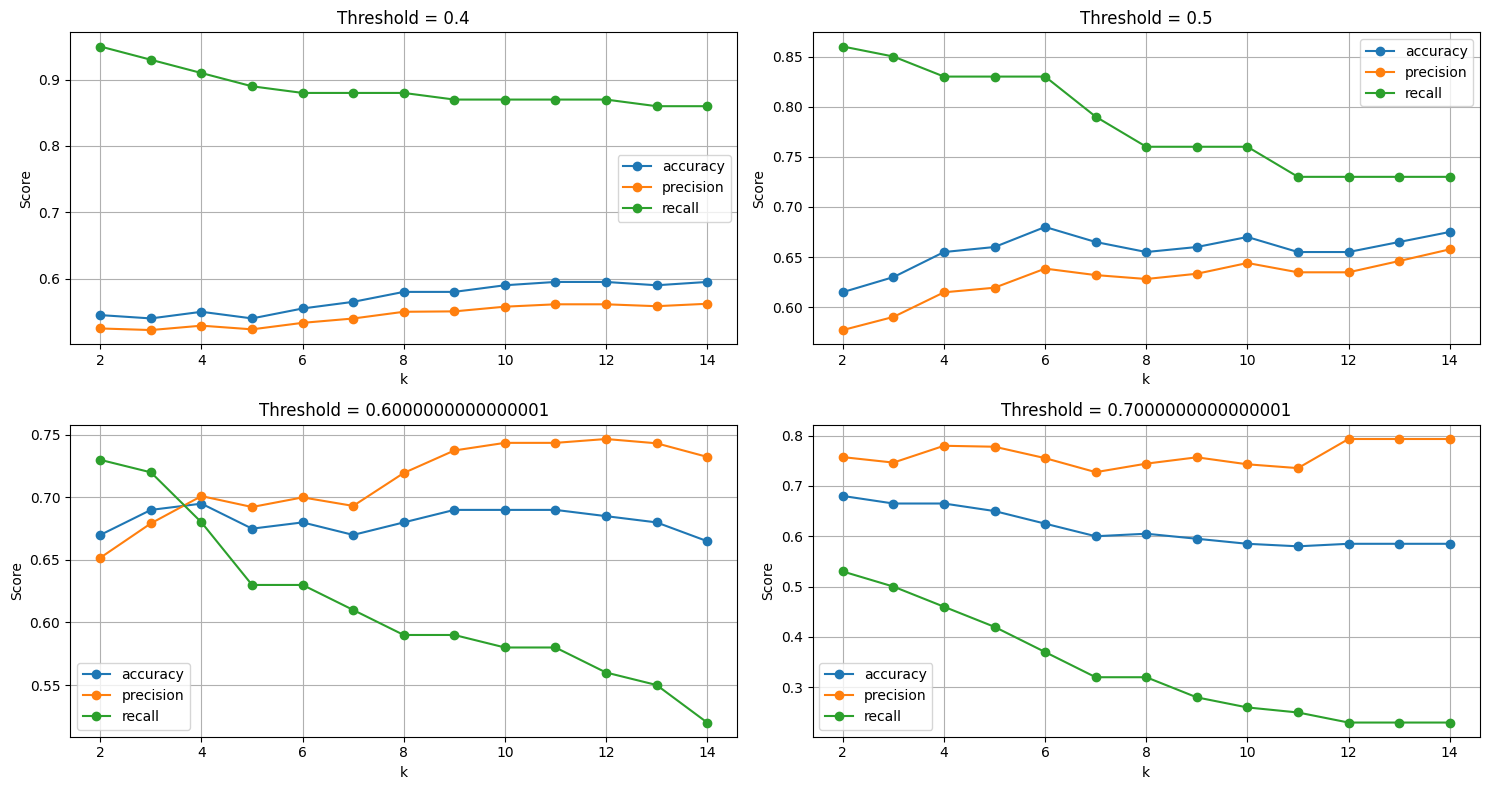

In [29]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall"]
thresholds = sorted(df_results["threshold"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8))  # 6 panels (for thresholds 0.4–0.9)
axes = axes.flatten()

for idx, t in enumerate(thresholds):
    ax = axes[idx]
    
    subset = df_results[df_results["threshold"] == t]
    
    for metric in metrics:
        ax.plot(subset["k"], subset[metric], marker='o', label=metric)
    
    ax.set_title(f"Threshold = {t}")
    ax.set_xlabel("k")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Another hypothesis

Convolutional smoothing improves the stability of model predictions by reinforcing locally consistent signals and reducing sensitivity to isolated high-probability windows. While this leads to more gradual precision-recall trade-offs, it slightly reduces peak precision due to attenuation of strong signals.

The effectiveness of signal smoothing depends on the granularity of text segmentation. Smaller windows produce more localized and consistent signals, allowing smoothing to reinforce true positives. Larger windows dilute these signals, causing smoothing to suppress borderline spoiler predictions and leading to sharp drops in recall.

Increasing the number of sampled windows does not significantly improve peak performance, but shifts the optimal aggregation threshold (k). In contrast, window size has a more substantial effect, with smaller windows improving recall by preserving localized spoiler signals, while larger windows improve precision at the cost of signal dilution.